# **Day 22: Linear Regression - OLS, Inference and Assumptions**
*Module 4 - Regression*

Linear regression is the most used model in science. It is fast, interpretable, has exact statistical theory, and is the **baseline** every complex model must beat.

> Linear regression fits a straight line (or plane) that predicts a number from inputs. Ordinary least squares chooses the line with the smallest squared errors. Its coefficients are easy to interpret, but the method relies on some assumptions we must check.
>
> *Example:* Predicting crop yield from NDVI: a coefficient of 4.2 means each 0.1 increase in NDVI adds about 0.42 t/ha to the predicted yield.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
rng = np.random.default_rng(22)

## **1. The Model**
$$y_i = \beta_0 + \beta_1x_{i1} + \dots + \beta_px_{ip} + \varepsilon_i,\qquad \varepsilon_i \sim \mathcal N(0, \sigma^2)$$
- $\beta_j$ = expected change in $y$ for a **one-unit** increase in $x_j$, **holding the other features constant**.
- OLS chooses $\boldsymbol\beta$ to minimise $\sum_i (y_i - \hat y_i)^2$, giving $\hat{\boldsymbol\beta} = (X^\top X)^{-1}X^\top\mathbf y$ (Day 7).

We simulate crop yield driven by NDVI, rainfall and temperature, with irrigation as a categorical factor.

In [2]:
n = 300
df = pd.DataFrame({"ndvi": rng.uniform(0.3, 0.9, n), "rain_mm": rng.normal(1000, 180, n),
                   "temp_c": rng.normal(30, 2, n), "irrigated": rng.choice(["no", "yes"], n, p=[0.6, 0.4])})
df["yield_t"] = (0.5 + 4.0 * df.ndvi + 0.0015 * df.rain_mm - 0.08 * df.temp_c
                 + 0.6 * (df.irrigated == "yes") + rng.normal(0, 0.3, n))
df.head()

,ndvi,rain_mm,temp_c,irrigated,yield_t
0,0.519808,1087.172067,30.382686,yes,2.406673
1,0.419577,711.276509,24.445483,no,1.055063
2,0.353135,744.921289,31.069289,no,0.393668
3,0.691915,862.523022,26.298119,no,2.391531
4,0.575602,927.369624,31.424181,no,1.766536


## **2. OLS From Scratch**

In [3]:
X = np.c_[np.ones(n), df[["ndvi", "rain_mm", "temp_c"]].values, (df.irrigated == "yes").astype(float)]
y = df.yield_t.values
beta = np.linalg.solve(X.T @ X, X.T @ y)
resid = y - X @ beta
p = X.shape[1]
sigma2 = resid @ resid / (n - p)                                  # unbiased noise variance
cov_beta = sigma2 * np.linalg.inv(X.T @ X)                        # Var(beta_hat) = sigma^2 (X^T X)^-1
se = np.sqrt(np.diag(cov_beta))
from scipy import stats
t = beta / se
pvals = 2 * stats.t.sf(np.abs(t), n - p)
r2 = 1 - resid @ resid / np.sum((y - y.mean()) ** 2)
pd.DataFrame({"coef": beta, "std_err": se, "t": t, "p_value": pvals},
             index=["intercept", "ndvi", "rain_mm", "temp_c", "irrigated"]).round(4).assign(R2=round(r2, 4))

,coef,std_err,t,p_value,R2
intercept,0.5470,0.2647,2.0668,0.0396,0.8922
ndvi,3.9542,0.1023,38.6628,0.0000,0.8922
rain_mm,0.0016,0.0001,16.7244,0.0000,0.8922
temp_c,-0.0828,0.0084,-9.8643,0.0000,0.8922
irrigated,0.6073,0.0352,17.2656,0.0000,0.8922


## **3. The Same With statsmodels (Formula API)**
The formula interface handles categorical variables (`C()`) and interactions (`*`, `:`) automatically.

In [4]:
model = smf.ols("yield_t ~ ndvi + rain_mm + temp_c + C(irrigated)", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                yield_t   R-squared:                       0.892
Model:                            OLS   Adj. R-squared:                  0.891
Method:                 Least Squares   F-statistic:                     610.6
Date:                Thu, 01 Oct 2026   Prob (F-statistic):          2.61e-141
Time:                        19:39:34   Log-Likelihood:                -55.923
No. Observations:                 300   AIC:                             121.8
Df Residuals:                     295   BIC:                             140.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.5470    

**Reading the table**
- `coef`: effect size. NDVI coefficient ~4: +0.1 NDVI -> +0.4 t/ha.
- `P>|t|` < 0.05: evidence that the coefficient is non-zero.
- `[0.025 0.975]`: 95% confidence interval.
- `R-squared` / `Adj. R-squared`: variance explained (adjusted penalises extra features).
- `F-statistic`: tests whether **any** coefficient is non-zero.

### Confidence vs prediction intervals
- **Confidence interval**: uncertainty about the **mean** yield for given features (narrow).
- **Prediction interval**: where a **new individual** field will fall (wide; includes $\sigma^2$).

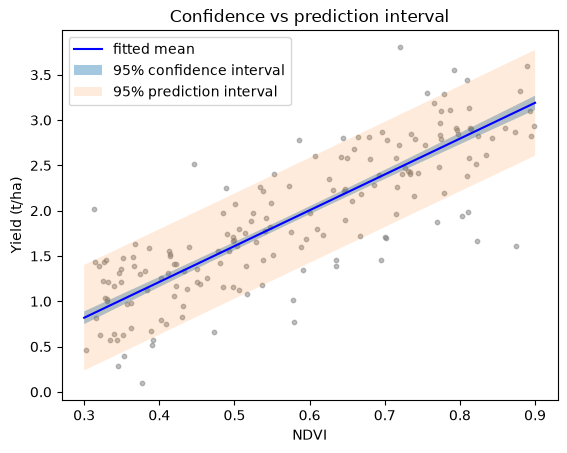

In [5]:
new = pd.DataFrame({"ndvi": np.linspace(0.3, 0.9, 50), "rain_mm": 1000, "temp_c": 30, "irrigated": "no"})
pr = model.get_prediction(new).summary_frame(alpha=0.05)
plt.scatter(df.ndvi[df.irrigated == "no"], df.yield_t[df.irrigated == "no"], s=10, c="grey", alpha=0.5)
plt.plot(new.ndvi, pr["mean"], "b", label="fitted mean")
plt.fill_between(new.ndvi, pr.mean_ci_lower, pr.mean_ci_upper, alpha=0.4, label="95% confidence interval")
plt.fill_between(new.ndvi, pr.obs_ci_lower, pr.obs_ci_upper, alpha=0.15, label="95% prediction interval")
plt.xlabel("NDVI"); plt.ylabel("Yield (t/ha)"); plt.legend(); plt.title("Confidence vs prediction interval"); plt.show()

## **4. Interactions**
Does NDVI matter more when the field is irrigated? `ndvi * C(irrigated)` adds the main effects and their interaction.

In [6]:
inter = smf.ols("yield_t ~ ndvi * C(irrigated) + rain_mm + temp_c", data=df).fit()
print(inter.summary().tables[1])
print(f"\nThe interaction term is {'NOT ' if inter.pvalues.filter(like=':').iloc[0] > 0.05 else ''}significant (the data were simulated without one).")

                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    0.5479      0.267      2.055      0.041       0.023       1.073
C(irrigated)[T.yes]          0.6034      0.131      4.590      0.000       0.345       0.862
ndvi                         3.9518      0.129     30.569      0.000       3.697       4.206
ndvi:C(irrigated)[T.yes]     0.0064      0.212      0.030      0.976      -0.411       0.423
rain_mm                      0.0016   9.41e-05     16.677      0.000       0.001       0.002
temp_c                      -0.0828      0.008     -9.812      0.000      -0.099      -0.066

The interaction term is NOT significant (the data were simulated without one).


## **5. Checking the Assumptions (LINE)**

| Assumption | Check | If violated |
|---|---|---|
| **L**inearity | Residuals vs fitted: no pattern | Transform features, add polynomial/spline terms |
| **I**ndependence | Domain knowledge; Durbin-Watson; spatial autocorrelation | Mixed models, time/spatial models |
| **N**ormality of residuals | Q-Q plot | Usually fine for large n (CLT); transform y |
| **E**qual variance (homoscedasticity) | Scale-location plot; Breusch-Pagan test | Transform y (log), robust SEs, WLS |

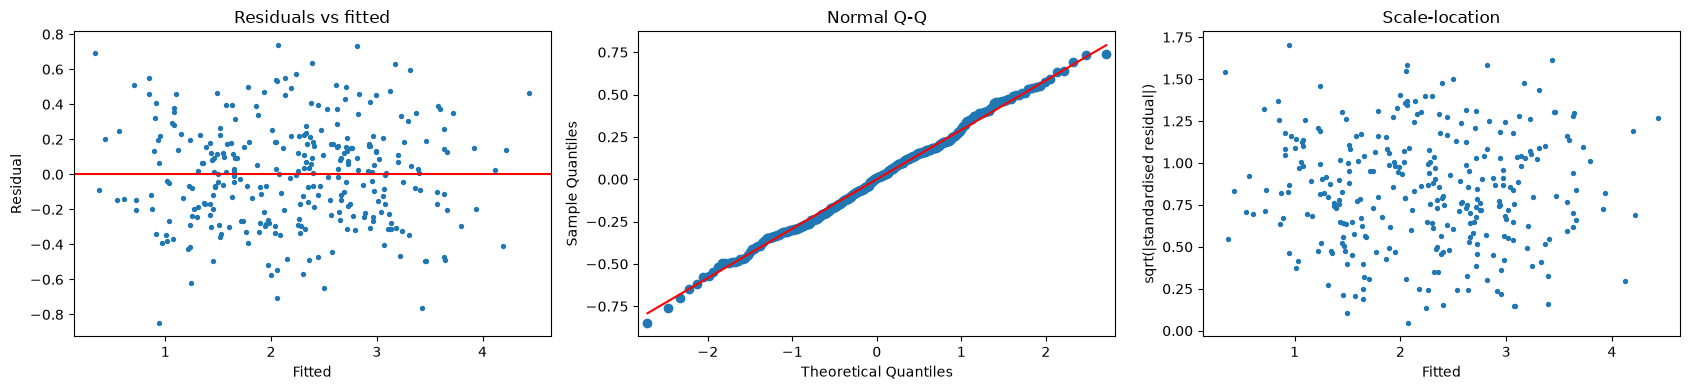

Breusch-Pagan p = 0.352 (p > 0.05: no evidence of heteroscedasticity)
Durbin-Watson = 2.00 (about 2 = no autocorrelation)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].scatter(model.fittedvalues, model.resid, s=8); axes[0].axhline(0, c="r")
axes[0].set(xlabel="Fitted", ylabel="Residual", title="Residuals vs fitted")
sm.qqplot(model.resid, line="s", ax=axes[1]); axes[1].set_title("Normal Q-Q")
axes[2].scatter(model.fittedvalues, np.sqrt(np.abs(model.get_influence().resid_studentized_internal)), s=8)
axes[2].set(xlabel="Fitted", ylabel="sqrt(|standardised residual|)", title="Scale-location")
plt.tight_layout(); plt.show()
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
print(f"Breusch-Pagan p = {het_breuschpagan(model.resid, model.model.exog)[1]:.3f} (p > 0.05: no evidence of heteroscedasticity)")
print(f"Durbin-Watson = {durbin_watson(model.resid):.2f} (about 2 = no autocorrelation)")

### What a violated assumption looks like

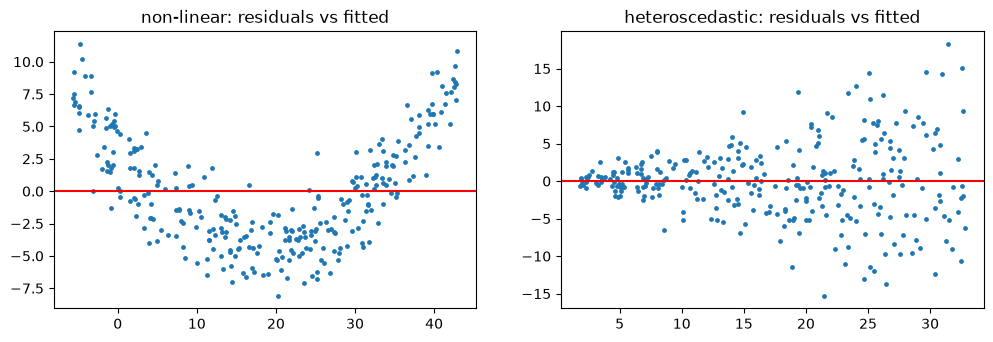

In [8]:
xb = rng.uniform(0, 10, 300)
cases = {"non-linear": 2 + 0.5 * xb ** 2 + rng.normal(0, 2, 300),
         "heteroscedastic": 2 + 3 * xb + rng.normal(0, 0.5 + 0.8 * xb, 300)}
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, (name, yb) in zip(axes, cases.items()):
    fit = sm.OLS(yb, sm.add_constant(xb)).fit()
    ax.scatter(fit.fittedvalues, fit.resid, s=6); ax.axhline(0, c="r"); ax.set_title(f"{name}: residuals vs fitted")
plt.show()

## **6. Multicollinearity and VIF**
If features are strongly correlated, coefficients become unstable and their standard errors explode (Day 7, condition number). The **VIF** of feature $j$ is $1/(1-R_j^2)$, where $R_j^2$ comes from regressing $x_j$ on all other features. Rule of thumb: VIF > 5-10 is a problem.

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
df["evi"] = 1.1 * df.ndvi + rng.normal(0, 0.02, n)              # nearly a copy of NDVI
Xv = sm.add_constant(df[["ndvi", "evi", "rain_mm", "temp_c"]])
print(pd.Series([variance_inflation_factor(Xv.values, i) for i in range(1, Xv.shape[1])], index=Xv.columns[1:], name="VIF").round(1))
m_col = smf.ols("yield_t ~ ndvi + evi + rain_mm + temp_c", data=df).fit()
print("\nWith both NDVI and EVI:\n", m_col.params[["ndvi", "evi"]].round(2).to_string(), "\nStd errors:\n", m_col.bse[["ndvi", "evi"]].round(2).to_string())

ndvi       91.6
evi        91.5
rain_mm     1.0
temp_c      1.0
Name: VIF, dtype: float64

With both NDVI and EVI:
 ndvi    2.62
evi     1.40 
Std errors:
 ndvi    1.36
evi     1.23


The **sum** of the NDVI and EVI effects is well determined, but how it is split between them is not. Fix: drop one, combine them, use PCA (Day 49) or Ridge (Day 24). Predictions are still fine; **interpretation** is what suffers.

# **Part 2: Going Deeper**

### Heteroscedasticity-robust (sandwich) standard errors
When variance is not constant, OLS coefficients are still unbiased but the classical SEs are wrong. White/HC3 standard errors fix inference without changing coefficients.

In [10]:
xh = rng.uniform(0, 10, 400); yh = 1 + 0.5 * xh + rng.normal(0, 0.2 + 0.3 * xh, 400)
classic = sm.OLS(yh, sm.add_constant(xh)).fit()
robust = sm.OLS(yh, sm.add_constant(xh)).fit(cov_type="HC3")
print(f"slope = {classic.params[1]:.3f} | classical SE = {classic.bse[1]:.4f} | HC3 robust SE = {robust.bse[1]:.4f}")

# Monte Carlo: which SE is right?
slopes = [sm.OLS(1 + 0.5 * xh + rng.normal(0, 0.2 + 0.3 * xh, 400), sm.add_constant(xh)).fit().params[1] for _ in range(2000)]
print(f"true sampling SD of the slope (simulation) = {np.std(slopes):.4f}")

slope = 0.530 | classical SE = 0.0331 | HC3 robust SE = 0.0364


true sampling SD of the slope (simulation) = 0.0350


### Influential points: leverage and Cook's distance
A point far from the others in feature space (high **leverage**) with a large residual can drag the whole line. **Cook's distance** measures how much all fitted values change when that point is removed (rule of thumb: > 4/n).

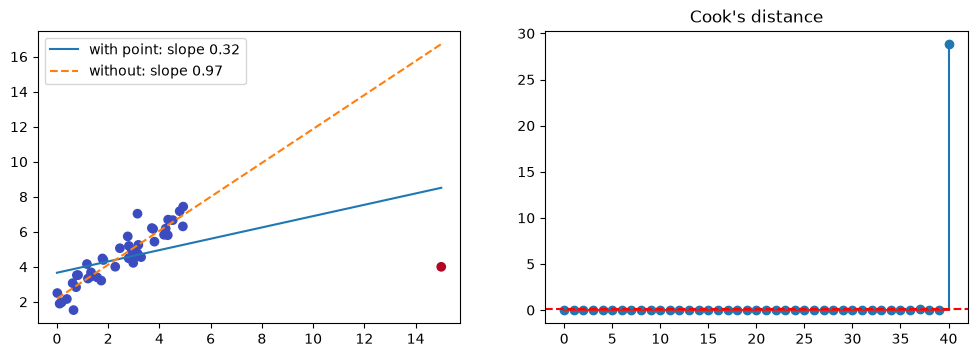

In [11]:
xi = np.r_[rng.uniform(0, 5, 40), 15]; yi = np.r_[2 + 1.0 * xi[:40] + rng.normal(0, 0.5, 40), 4]
fit_i = sm.OLS(yi, sm.add_constant(xi)).fit()
cooks = fit_i.get_influence().cooks_distance[0]
fit_wo = sm.OLS(yi[:-1], sm.add_constant(xi[:-1])).fit()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].scatter(xi, yi, c=cooks > 4 / len(xi), cmap="coolwarm"); xs = np.linspace(0, 15, 10)
axes[0].plot(xs, fit_i.params[0] + fit_i.params[1] * xs, label=f"with point: slope {fit_i.params[1]:.2f}")
axes[0].plot(xs, fit_wo.params[0] + fit_wo.params[1] * xs, "--", label=f"without: slope {fit_wo.params[1]:.2f}"); axes[0].legend()
axes[1].stem(cooks); axes[1].axhline(4 / len(xi), c="r", ls="--"); axes[1].set_title("Cook's distance")
plt.show()

## **Practice Problems**
1. Fit `yield_t ~ ndvi` only. How does the NDVI coefficient change compared with the full model? Why (omitted-variable bias / correlation)?
2. Compute R^2 and adjusted R^2 by hand for the full model.
3. Log-transform the heteroscedastic example (`log(y)`) and re-run the Breusch-Pagan test.
4. *(Advanced)* Show that with 50 pure-noise features, R^2 increases but adjusted R^2 does not.

In [12]:
# Solution 1
print("NDVI only:", smf.ols("yield_t ~ ndvi", df).fit().params["ndvi"].round(3), "| full model:", model.params["ndvi"].round(3),
      "-> similar here because NDVI was simulated independent of the other features")
# Solution 2
ss_res = np.sum(model.resid ** 2); ss_tot = np.sum((df.yield_t - df.yield_t.mean()) ** 2); k = 4
r2_ = 1 - ss_res / ss_tot; adj = 1 - (1 - r2_) * (n - 1) / (n - k - 1)
print(f"R2 {r2_:.4f} (sm {model.rsquared:.4f}) | adj R2 {adj:.4f} (sm {model.rsquared_adj:.4f})")
# Solution 3
yh_pos = np.exp(0.1 * xh + rng.normal(0, 0.2, 400))           # multiplicative noise
for name, target in [("y", yh_pos), ("log(y)", np.log(yh_pos))]:
    f = sm.OLS(target, sm.add_constant(xh)).fit(); print(f"{name}: Breusch-Pagan p = {het_breuschpagan(f.resid, f.model.exog)[1]:.4f}")
# Solution 4
noise = pd.DataFrame(rng.normal(size=(n, 50)), columns=[f"z{i}" for i in range(50)])
big = sm.OLS(df.yield_t, sm.add_constant(pd.concat([df[["ndvi", "rain_mm", "temp_c"]], noise], axis=1))).fit()
small = sm.OLS(df.yield_t, sm.add_constant(df[["ndvi", "rain_mm", "temp_c"]])).fit()
print(f"R2 {small.rsquared:.4f} -> {big.rsquared:.4f} | adj R2 {small.rsquared_adj:.4f} -> {big.rsquared_adj:.4f}")

NDVI only: 4.123 | full model: 3.954 -> similar here because NDVI was simulated independent of the other features
R2 0.8922 (sm 0.8922) | adj R2 0.8908 (sm 0.8908)
y: Breusch-Pagan p = 0.0000
log(y): Breusch-Pagan p = 0.1733
R2 0.7833 -> 0.8099 | adj R2 0.7811 -> 0.7690


## **Key References**
- Fox, J. (2016). *Applied Regression Analysis and Generalized Linear Models* (3rd ed.). SAGE.
- Gelman, A., Hill, J., & Vehtari, A. (2020). *Regression and Other Stories*. Cambridge University Press.
- White, H. (1980). A heteroskedasticity-consistent covariance matrix estimator and a direct test for heteroskedasticity. *Econometrica*, 48(4), 817-838.
- Cook, R. D. (1977). Detection of influential observation in linear regression. *Technometrics*, 19(1), 15-18.
- Seabold, S., & Perktold, J. (2010). statsmodels: Econometric and statistical modeling with Python. *Proceedings of the 9th Python in Science Conference*.